# Segmentación de Clientes con K-means

Este notebook demuestra cómo usar Claude para realizar un análisis completo de segmentación de clientes.

**Flujo del análisis:**
1. Generación de datos sintéticos
2. Análisis exploratorio (EDA)
3. Preprocesamiento
4. Determinación del K óptimo
5. Clustering con K-means
6. Visualización e interpretación

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA
from sklearn.metrics import silhouette_score

np.random.seed(42)
plt.style.use('seaborn-v0_8-whitegrid')
print('Librerías cargadas correctamente')

Librerías cargadas correctamente


## 1. Generación de Datos Sintéticos

Simulamos un dataset de clientes de e-commerce con variables de comportamiento de compra.

In [2]:
n_customers = 500

data = pd.DataFrame({
    'customer_id': range(1, n_customers + 1),
    'gasto_anual': np.concatenate([
        np.random.normal(2000, 500, 200),   # Bajo gasto
        np.random.normal(5000, 1000, 200),  # Gasto medio
        np.random.normal(12000, 2000, 100)  # Alto gasto
    ]),
    'frecuencia_compra': np.concatenate([
        np.random.normal(3, 1, 200),   # Baja frecuencia
        np.random.normal(8, 2, 200),   # Media frecuencia
        np.random.normal(15, 3, 100)   # Alta frecuencia
    ]),
    'ticket_promedio': np.concatenate([
        np.random.normal(50, 15, 200),
        np.random.normal(120, 30, 200),
        np.random.normal(250, 50, 100)
    ]),
    'dias_desde_ultima_compra': np.concatenate([
        np.random.normal(90, 30, 200),
        np.random.normal(30, 10, 200),
        np.random.normal(10, 5, 100)
    ])
})

# Asegurar valores positivos
for col in ['gasto_anual', 'frecuencia_compra', 'ticket_promedio', 'dias_desde_ultima_compra']:
    data[col] = data[col].clip(lower=0.1)

print(f'Dataset: {data.shape[0]} clientes, {data.shape[1]} columnas')
data.head(10)

Dataset: 500 clientes, 5 columnas


,customer_id,gasto_anual,frecuencia_compra,ticket_promedio,dias_desde_ultima_compra
0,1,2248.357077,3.926178,70.990332,113.350832
1,2,1930.867849,4.909417,63.869505,73.464429
2,3,2323.844269,1.601432,50.894456,65.454033
3,4,2761.514928,3.562969,40.295948,89.898766
4,5,1882.923313,2.349357,60.473350,84.894461
5,6,1882.931522,2.512875,55.902281,76.403159
6,7,2789.606408,2.407606,63.427898,110.891623
7,8,2383.717365,2.136009,59.527577,118.659156
8,9,1765.262807,3.048522,65.743291,92.652207
9,10,2271.280022,2.169050,41.971472,134.325902


## 2. Análisis Exploratorio (EDA)

In [3]:
features = ['gasto_anual', 'frecuencia_compra', 'ticket_promedio', 'dias_desde_ultima_compra']

print('=== Estadísticas Descriptivas ===')
print(data[features].describe().round(2))
print('\n=== Valores Nulos ===')
print(data[features].isnull().sum())

=== Estadísticas Descriptivas ===
       gasto_anual  frecuencia_compra  ticket_promedio  \
count       500.00             500.00           500.00   
mean       5203.79               7.49           121.51   
std        3807.69               4.85            83.10   
min         690.13               0.30             6.56   
25%        2129.65               3.27            56.52   
50%        4388.54               6.87            99.86   
75%        6141.20              10.21           155.93   
max       18157.76              21.49           380.08   

       dias_desde_ultima_compra  
count                    500.00  
mean                      50.53  
std                       39.31  
min                        0.10  
25%                       19.43  
50%                       35.56  
75%                       80.53  
max                      185.79  

=== Valores Nulos ===
gasto_anual                 0
frecuencia_compra           0
ticket_promedio             0
dias_desde_ultima_compra

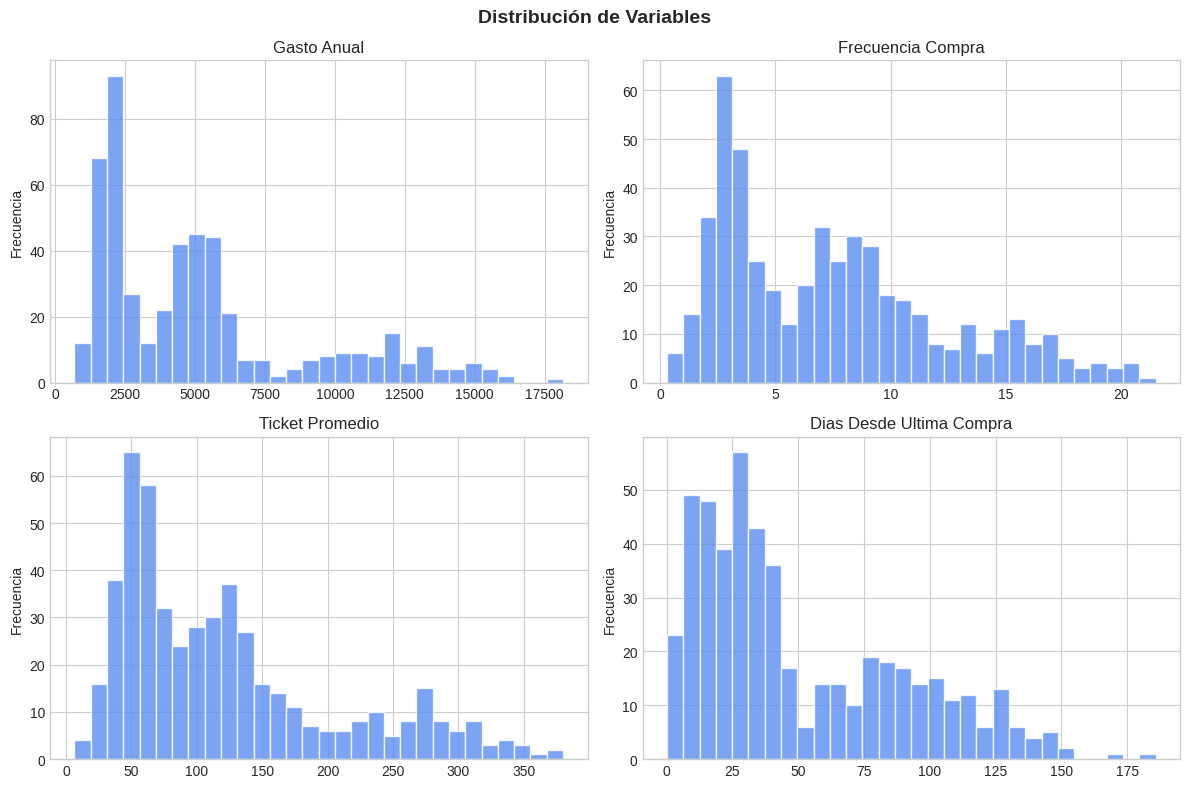

In [4]:
fig, axes = plt.subplots(2, 2, figsize=(12, 8))
fig.suptitle('Distribución de Variables', fontsize=14, fontweight='bold')

for i, col in enumerate(features):
    ax = axes[i // 2][i % 2]
    ax.hist(data[col], bins=30, color='#5B8DEF', edgecolor='white', alpha=0.8)
    ax.set_title(col.replace('_', ' ').title())
    ax.set_ylabel('Frecuencia')

plt.tight_layout()
plt.show()

## 3. Preprocesamiento

In [5]:
scaler = StandardScaler()
X_scaled = scaler.fit_transform(data[features])

print(f'Shape de datos escalados: {X_scaled.shape}')
print(f'Media por feature (debe ser ~0): {X_scaled.mean(axis=0).round(4)}')
print(f'Std por feature (debe ser ~1): {X_scaled.std(axis=0).round(4)}')

Shape de datos escalados: (500, 4)
Media por feature (debe ser ~0): [ 0. -0.  0. -0.]
Std por feature (debe ser ~1): [1. 1. 1. 1.]


## 4. Determinación del K Óptimo

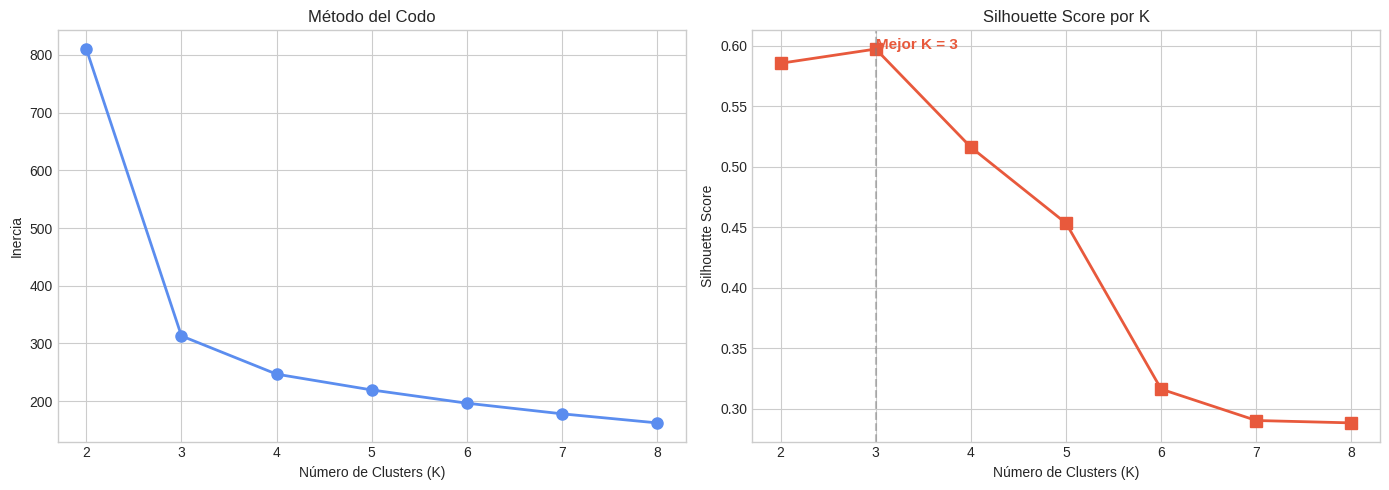


K óptimo por silhouette score: 3


In [6]:
K_range = range(2, 9)
inertias = []
silhouette_scores = []

for k in K_range:
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    km.fit(X_scaled)
    inertias.append(km.inertia_)
    silhouette_scores.append(silhouette_score(X_scaled, km.labels_))

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

ax1.plot(K_range, inertias, 'o-', color='#5B8DEF', linewidth=2, markersize=8)
ax1.set_xlabel('Número de Clusters (K)')
ax1.set_ylabel('Inercia')
ax1.set_title('Método del Codo')

ax2.plot(K_range, silhouette_scores, 's-', color='#E8593C', linewidth=2, markersize=8)
ax2.set_xlabel('Número de Clusters (K)')
ax2.set_ylabel('Silhouette Score')
ax2.set_title('Silhouette Score por K')

best_k = list(K_range)[np.argmax(silhouette_scores)]
ax2.axvline(x=best_k, color='gray', linestyle='--', alpha=0.5)
ax2.annotate(f'Mejor K = {best_k}', xy=(best_k, max(silhouette_scores)),
             fontsize=11, fontweight='bold', color='#E8593C')

plt.tight_layout()
plt.show()
print(f'\nK óptimo por silhouette score: {best_k}')

## 5. Clustering con K-means

In [7]:
kmeans = KMeans(n_clusters=best_k, random_state=42, n_init=10)
data['cluster'] = kmeans.fit_predict(X_scaled)

print(f'Distribución de clusters:')
print(data['cluster'].value_counts().sort_index())
print(f'\nCentroides (escala original):')

centroids = data.groupby('cluster')[features].mean().round(2)
centroids

Distribución de clusters:
cluster
0    195
1    100
2    205
Name: count, dtype: int64

Centroides (escala original):


,gasto_anual,frecuencia_compra,ticket_promedio,dias_desde_ultima_compra
cluster,,,,
0,1976.97,2.95,51.94,92.97
1,11887.99,15.08,263.22,10.52
2,5012.62,8.10,118.56,29.67


## 6. Visualización de Clusters

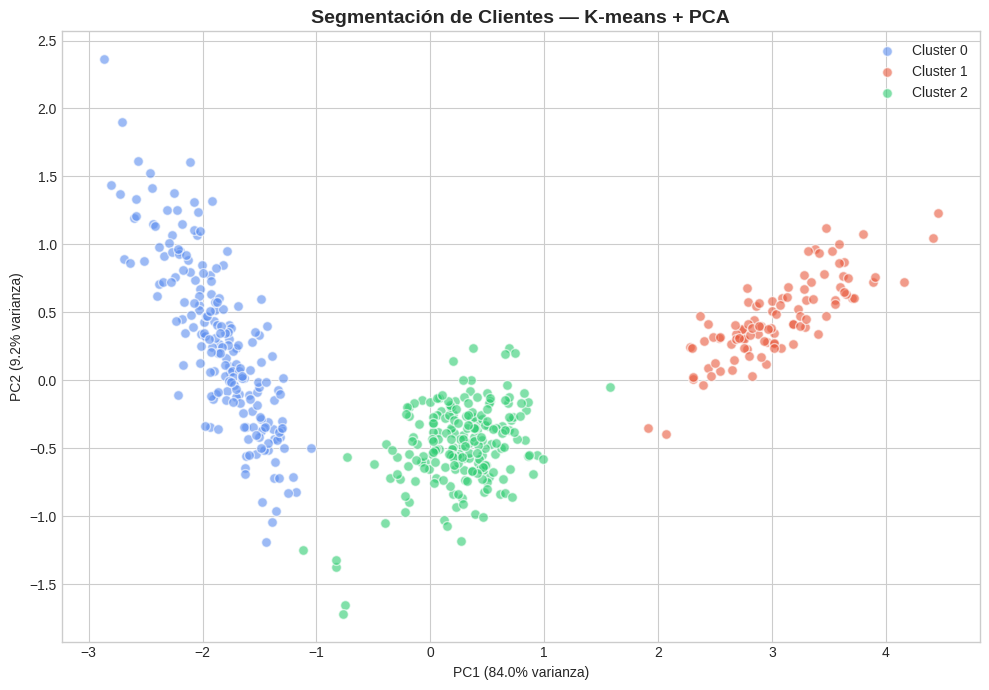

In [8]:
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)

colors = ['#5B8DEF', '#E8593C', '#2ECC71', '#F39C12', '#9B59B6']

fig, ax = plt.subplots(figsize=(10, 7))
for i in range(best_k):
    mask = data['cluster'] == i
    ax.scatter(X_pca[mask, 0], X_pca[mask, 1],
              c=colors[i], label=f'Cluster {i}', alpha=0.6, s=50, edgecolors='white')

ax.set_xlabel(f'PC1 ({pca.explained_variance_ratio_[0]:.1%} varianza)')
ax.set_ylabel(f'PC2 ({pca.explained_variance_ratio_[1]:.1%} varianza)')
ax.set_title('Segmentación de Clientes — K-means + PCA', fontsize=14, fontweight='bold')
ax.legend()
plt.tight_layout()
plt.show()

## 7. Exportar Resultados

El dataset con la columna de cluster asignada se exporta a Excel.

In [9]:
output_path = 'clientes_segmentados.xlsx'
data.to_excel(output_path, index=False)
print(f'Archivo exportado: {output_path}')
print(f'Total de registros: {len(data)}')
print(f'Columnas: {list(data.columns)}')

Archivo exportado: clientes_segmentados.xlsx
Total de registros: 500
Columnas: ['customer_id', 'gasto_anual', 'frecuencia_compra', 'ticket_promedio', 'dias_desde_ultima_compra', 'cluster']
